In [1]:
import pandas as pd
df = pd.read_csv( r"C:\Users\SHINCHAN\Desktop\Crop_Suitability_Capstone\Crop_recommendation.csv")
print("Dataset loaded successfully!")
print(df.shape)
df.head()


Dataset loaded successfully!
(2200, 8)


,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [2]:
df.columns.tolist()


['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label']

In [3]:
df.dtypes

N                int64
P                int64
K                int64
temperature    float64
humidity       float64
ph             float64
rainfall       float64
label           object
dtype: object

In [4]:
df.head(10)

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice
5,69,37,42,23.058049,83.370118,7.073454,251.055000,rice
6,69,55,38,22.708838,82.639414,5.700806,271.324860,rice
7,94,53,40,20.277744,82.894086,5.718627,241.974195,rice
8,89,54,38,24.515881,83.535216,6.685346,230.446236,rice
9,68,58,38,23.223974,83.033227,6.336254,221.209196,rice


In [5]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB


In [6]:
df.describe()

,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


In [7]:
#Investigation
print("Missing values")
print(df.isnull().sum())
print("Dplicate rows")
print(df.duplicated().sum())




Missing values
N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64
Dplicate rows
0


In [8]:
df["label"].unique()



array(['rice', 'maize', 'chickpea', 'kidneybeans', 'pigeonpeas',
       'mothbeans', 'mungbean', 'blackgram', 'lentil', 'pomegranate',
       'banana', 'mango', 'grapes', 'watermelon', 'muskmelon', 'apple',
       'orange', 'papaya', 'coconut', 'cotton', 'jute', 'coffee'],
      dtype=object)

In [9]:
df["label"].nunique()

22

In [10]:
df["label"].value_counts()

label
rice           100
maize          100
jute           100
cotton         100
coconut        100
papaya         100
orange         100
apple          100
muskmelon      100
watermelon     100
grapes         100
mango          100
banana         100
pomegranate    100
lentil         100
blackgram      100
mungbean       100
mothbeans      100
pigeonpeas     100
kidneybeans    100
chickpea       100
coffee         100
Name: count, dtype: int64

In [11]:
#range and outlier validation
df.columns

Index(['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label'], dtype='object')

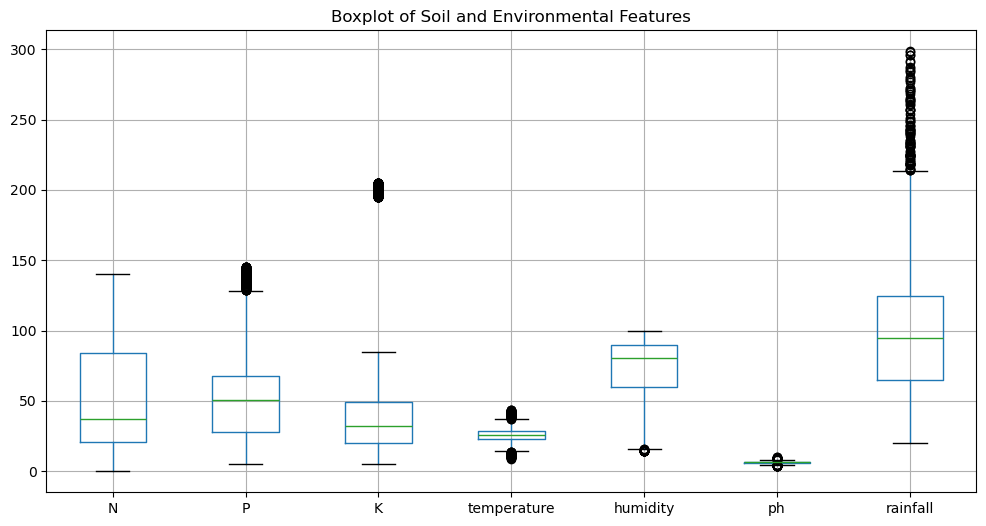

In [12]:
import matplotlib.pyplot as plt

numeric_cols = ["N", "P", "K", "temperature", "humidity", "ph", "rainfall"]

df[numeric_cols].boxplot(figsize=(12, 6))
plt.title("Boxplot of Soil and Environmental Features")
plt.show()

In [13]:
#check range of each feature
display(df.groupby("label")[numeric_cols].agg(["min","max"]))


N         P         K      temperature              humidity  \
             min  max  min  max  min  max         min        max        min   
label                                                                         
apple          0   40  120  145  195  205   21.036527  23.996862  90.025751   
banana        80  120   70   95   45   55   25.010185  29.908885  75.031933   
blackgram     20   60   55   80   15   25   25.097374  34.946616  60.065349   
chickpea      20   60   55   80   75   85   17.024985  20.995022  14.258040   
coconut        0   40    5   30   25   35   25.008724  29.869083  90.017345   
coffee        80  120   15   40   25   35   23.059519  27.923744  50.045570   
cotton       100  140   35   60   15   25   22.000851  25.992374  75.005393   
grapes         0   40  120  145  195  205    8.825675  41.948657  80.016394   
jute          60  100   35   60   35   45   23.094338  26.985822  70.882596   
kidneybeans    0   40   55   80   15   25   15.330426  24.923601  18.092240   
lentil         0   40   55   80   15   25   18.064861  29.944139  60.091166   
maize         60  100   35   60   15   25   18.041855  26.549864  55.282204   
mango          0   40   15   40   25   35   27.003155  35.990097  45.022364   
mothbeans      0   40   35   60   15   25   24.018254  31.999286  40.009334   
mungbean       0   40   35   60   15   25   27.014704  29.914544  80.034996   
muskmelon     80  120    5   30   45   55   27.024151  29.943492  90.015064   
orange         0   40    5   30    5   15   10.010813  34.906653  90.006217   
papaya        31   70   46   70   45   55   23.012402  43.675493  90.038631   
pigeonpeas     0   40   55   80   15   25   18.319104  36.977944  30.400468   
pomegranate    0   40    5   30   35   45   18.071330  24.962732  85.129122   
rice          60   99   35   60   35   45   20.045414  26.929951  80.122675   
watermelon    80  120    5   30   45   55   24.043558  26.986037  80.026213   

                              ph              rainfall              
                   max       min       max         min         max  
label                                                               
apple        94.920481  5.514253  6.499227  100.117344  124.983162  
banana       84.978492  5.505394  6.490074   90.109781  119.847970  
blackgram    69.961000  6.500145  7.775306   60.417903   74.915595  
chickpea     19.969789  5.988993  8.868741   65.113656   94.781896  
coconut      99.981876  5.501580  6.470466  131.090008  225.632366  
coffee       69.948073  6.020947  7.493192  115.156401  199.473564  
cotton       84.876690  5.801048  7.994680   60.653817   99.931008  
grapes       83.983517  5.510925  6.499605   65.010953   74.915062  
jute         89.891065  6.002525  7.488014  150.235524  199.836291  
kidneybeans  24.969699  5.502999  5.998125   60.275525  149.744103  
lentil       69.923759  5.916454  7.841496   35.034848   54.939377  
maize        74.829137  5.513698  6.995844   60.651715  109.751538  
mango        54.964053  4.507524  6.967418   89.291476  100.812466  
mothbeans    64.955854  3.504752  9.935091   30.920140   74.443307  
mungbean     89.996156  6.218924  7.199495   36.120429   59.872321  
muskmelon    94.962187  6.002927  6.781050   20.211267   29.866814  
orange       94.964199  6.010392  7.995849  100.173796  119.694658  
papaya       94.944821  6.501521  6.993473   40.351531  248.859299  
pigeonpeas   69.691413  4.548202  7.445445   90.054227  198.829881  
pomegranate  94.998975  5.561852  7.199504  102.518476  112.475094  
rice         84.969072  5.005307  7.868475  182.561632  298.560117  
watermelon   89.984052  6.000976  6.956509   40.126504   59.759800

In [14]:
df.describe().loc["min"]

N               0.000000
P               5.000000
K               5.000000
temperature     8.825675
humidity       14.258040
ph              3.504752
rainfall       20.211267
Name: min, dtype: float64

In [15]:
print(df.isnull().sum())
print(df.isin([float("inf"), float("-inf")]).sum())


N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64
N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64


In [16]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


label
rice           100
maize          100
jute           100
cotton         100
coconut        100
papaya         100
orange         100
apple          100
muskmelon      100
watermelon     100
grapes         100
mango          100
banana         100
pomegranate    100
lentil         100
blackgram      100
mungbean       100
mothbeans      100
pigeonpeas     100
kidneybeans    100
chickpea       100
coffee         100
Name: count, dtype: int64


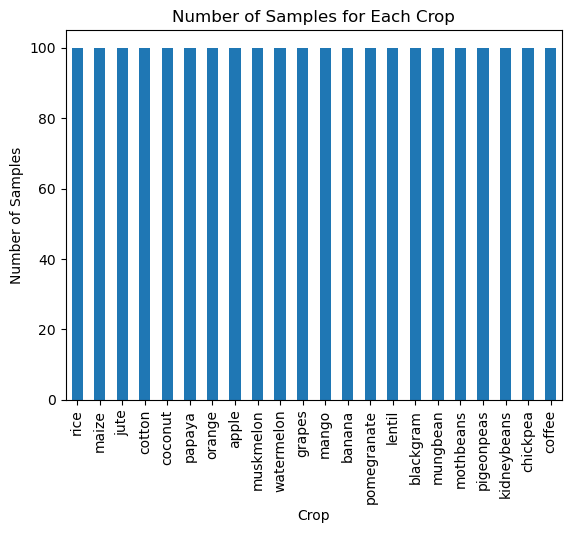

In [17]:
import matplotlib.pyplot as plt
crop_counts = df["label"].value_counts()
print(crop_counts)
crop_counts.plot(kind="bar")
plt.title("Number of Samples for Each Crop")
plt.xlabel("Crop")
plt.ylabel("Number of Samples")
plt.show()

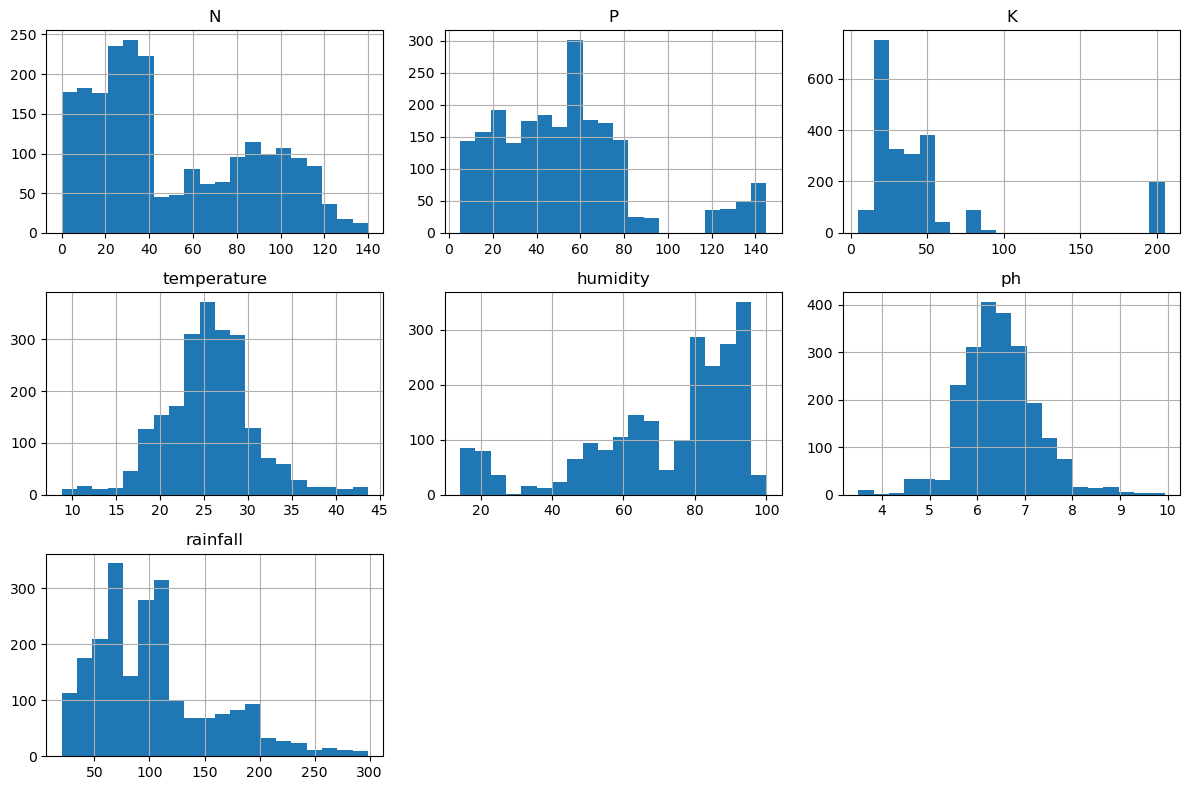

In [18]:
df.hist(figsize=(12, 8), bins=20)
plt.title("Distribution of Soil and Environmental Features")
plt.tight_layout()
plt.show()

In [19]:
X = df.drop("label", axis=1)
y = df["label"]
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (2200, 7)
y shape: (2200,)


In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)
X_train.shape
X_test.shape

(440, 7)

In [21]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [22]:
scaler.fit_transform(X_train)

array([[-1.37162846, -1.07290957, -0.67351002, ...,  0.92439516,
         0.93754456,  0.1994396 ],
       [-1.12741063,  2.08451298,  3.01526081, ...,  0.42661263,
        -1.15384595, -0.64367687],
       [-1.07314   ,  0.53616154, -0.47624954, ..., -2.18629069,
        -1.10745175,  0.69400094],
       ...,
       [ 0.8534673 , -0.1621146 , -0.23953698, ...,  0.46475923,
        -0.15548263,  1.63323326],
       [ 1.07054981, -0.10139494, -0.0817286 , ...,  0.09292232,
        -0.28148439,  1.23724576],
       [-1.34449314,  2.3881113 ,  2.99553476, ...,  0.51745   ,
        -1.08941335, -0.67077084]], shape=(1760, 7))

In [23]:
scaler.transform(X_test)

array([[-1.01886937, -0.92111041, -0.83131839, ...,  0.84613888,
         1.13848097, -0.01374611],
       [ 1.28763233,  0.77904019,  0.03662768, ...,  0.58616143,
        -0.04841589, -0.2253062 ],
       [ 2.42731552, -0.46571293, -0.65378397, ...,  0.20050841,
        -0.57771584, -0.60999985],
       ...,
       [ 0.52784353, -0.46571293, -0.25926302, ...,  0.35250427,
         0.68989384,  1.10624666],
       [-0.80178686,  2.44883096,  3.03498685, ...,  0.38629579,
        -0.06182135, -0.69398814],
       [-0.39475715,  0.41472221, -0.4565235 , ..., -1.56631835,
        -0.0712168 ,  0.59286777]], shape=(440, 7))

In [24]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)


In [25]:
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
accuracy_knn = accuracy_score(y_test, y_pred_knn)
print("KNN Accuracy:", accuracy_knn)

KNN Accuracy: 0.9795454545454545


In [26]:
print(classification_report(y_test, y_pred_knn))

              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      1.00      1.00        20
    chickpea       1.00      1.00      1.00        20
     coconut       0.95      1.00      0.98        20
      coffee       1.00      1.00      1.00        20
      cotton       0.95      1.00      0.98        20
      grapes       1.00      1.00      1.00        20
        jute       0.95      1.00      0.98        20
 kidneybeans       0.95      1.00      0.98        20
      lentil       0.91      1.00      0.95        20
       maize       1.00      0.95      0.97        20
       mango       0.95      1.00      0.98        20
   mothbeans       0.94      0.85      0.89        20
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00      1.00      1.00        20
      orange       1.00      0.90      0.95        20
      papaya       1.00    

In [27]:
#decision trees do not need scaling 
from sklearn.tree import DecisionTreeClassifier 
dt=DecisionTreeClassifier(random_state=42)
dt.fit(X_train,y_train)


,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [28]:
y_pred_dt=dt.predict(X_test)
accuracy_dt=accuracy_score(y_test,y_pred_dt)
print("Decision tree Accuracy ",accuracy_dt)

Decision tree Accuracy  0.9795454545454545


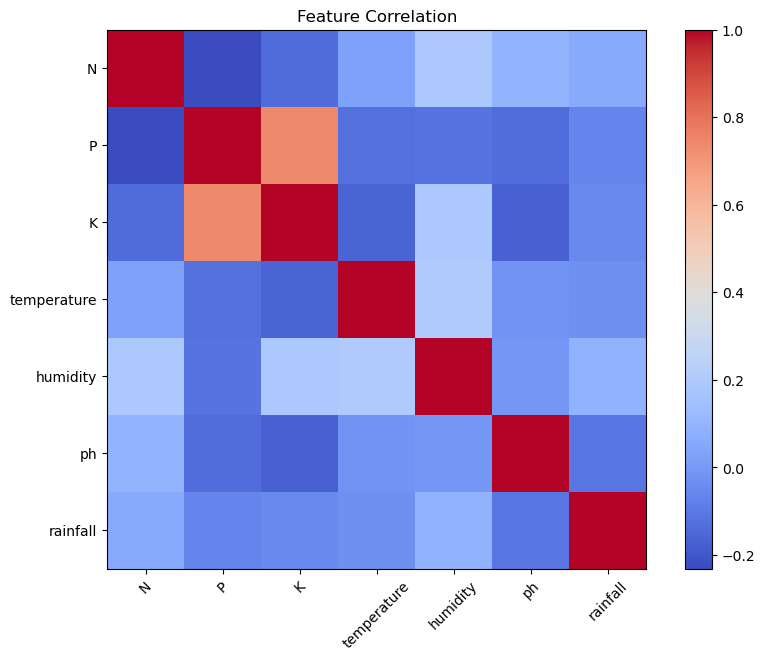

In [29]:
corr = df.drop("label", axis=1).corr()
plt.figure(figsize=(10, 7))
plt.imshow(corr, cmap="coolwarm")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Feature Correlation")
plt.show()

In [30]:
"""
Feature Relationships
The correlation matrix was used to understand the relationships between the numerical features. Most features show relatively low correlation with each other, while phosphorus (P) and potassium (K) show a stronger positive relationship.
"""

'\nFeature Relationships\nThe correlation matrix was used to understand the relationships between the numerical features. Most features show relatively low correlation with each other, while phosphorus (P) and potassium (K) show a stronger positive relationship.\n'

In [31]:

# Logistic Regression works better when numerical features are on a similar scale, so we use the scaled data.

from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(random_state=42)
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)
accuracy_lr = accuracy_score(y_test, y_pred_lr)
print("Logistic Regression Accuracy:", accuracy_lr)

Logistic Regression Accuracy: 0.9727272727272728


In [32]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       0.95      1.00      0.98        20
    chickpea       1.00      1.00      1.00        20
     coconut       0.95      1.00      0.98        20
      coffee       1.00      1.00      1.00        20
      cotton       0.95      1.00      0.98        20
      grapes       1.00      1.00      1.00        20
        jute       0.83      1.00      0.91        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       0.94      0.85      0.89        20
       maize       1.00      0.95      0.97        20
       mango       0.95      1.00      0.98        20
   mothbeans       0.90      0.90      0.90        20
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00      1.00      1.00        20
      orange       1.00      0.95      0.97        20
      papaya       1.00    

In [33]:
print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      0.80      0.89        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        20
        jute       0.95      0.95      0.95        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       0.86      0.90      0.88        20
       maize       0.95      1.00      0.98        20
       mango       1.00      1.00      1.00        20
   mothbeans       0.86      0.95      0.90        20
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00      1.00      1.00        20
      orange       1.00      1.00      1.00        20
      papaya       1.00    

In [34]:
print(classification_report(y_test, y_pred_knn))

              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      1.00      1.00        20
    chickpea       1.00      1.00      1.00        20
     coconut       0.95      1.00      0.98        20
      coffee       1.00      1.00      1.00        20
      cotton       0.95      1.00      0.98        20
      grapes       1.00      1.00      1.00        20
        jute       0.95      1.00      0.98        20
 kidneybeans       0.95      1.00      0.98        20
      lentil       0.91      1.00      0.95        20
       maize       1.00      0.95      0.97        20
       mango       0.95      1.00      0.98        20
   mothbeans       0.94      0.85      0.89        20
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00      1.00      1.00        20
      orange       1.00      0.90      0.95        20
      papaya       1.00    

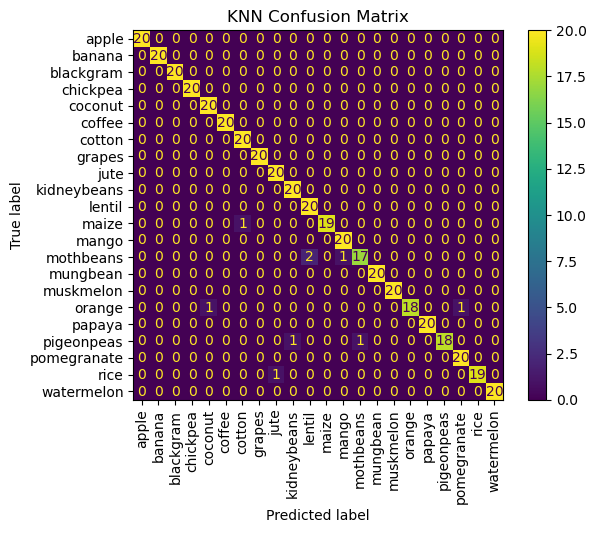

In [35]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
cm_knn = confusion_matrix(y_test, y_pred_knn)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_knn, display_labels=knn.classes_ )
disp.plot(xticks_rotation=90)
plt.title("KNN Confusion Matrix")
plt.show()

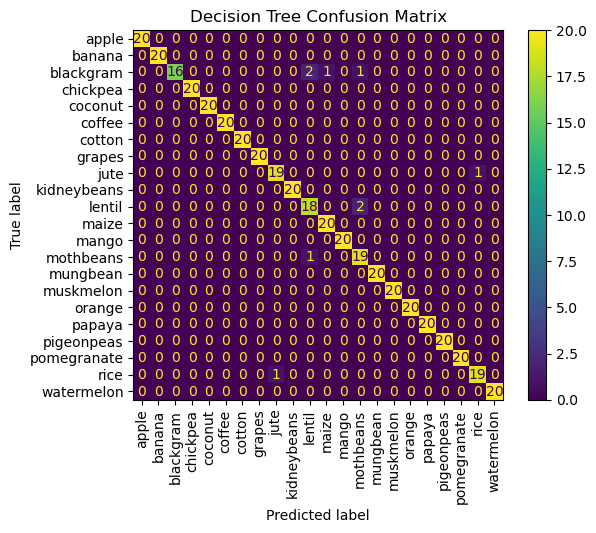

In [36]:
cm_dt = confusion_matrix(y_test, y_pred_dt)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_dt, display_labels=dt.classes_)
disp.plot(xticks_rotation=90)
plt.title("Decision Tree Confusion Matrix")
plt.show()

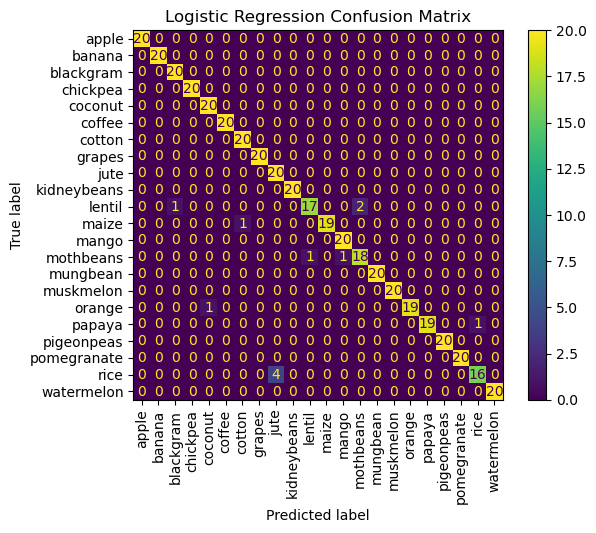

In [37]:
cm_lr = confusion_matrix(y_test, y_pred_lr)
disp = ConfusionMatrixDisplay( confusion_matrix=cm_lr, display_labels=lr.classes_)
disp.plot(xticks_rotation=90)
plt.title("Logistic Regression Confusion Matrix")
plt.show()

In [38]:
feature_importance=pd.Series(dt.feature_importances_,index=X.columns).sort_values(ascending=False)
print(feature_importance)

rainfall       0.354324
P              0.224962
humidity       0.149258
K              0.110846
N              0.098830
temperature    0.054377
ph             0.007404
dtype: float64


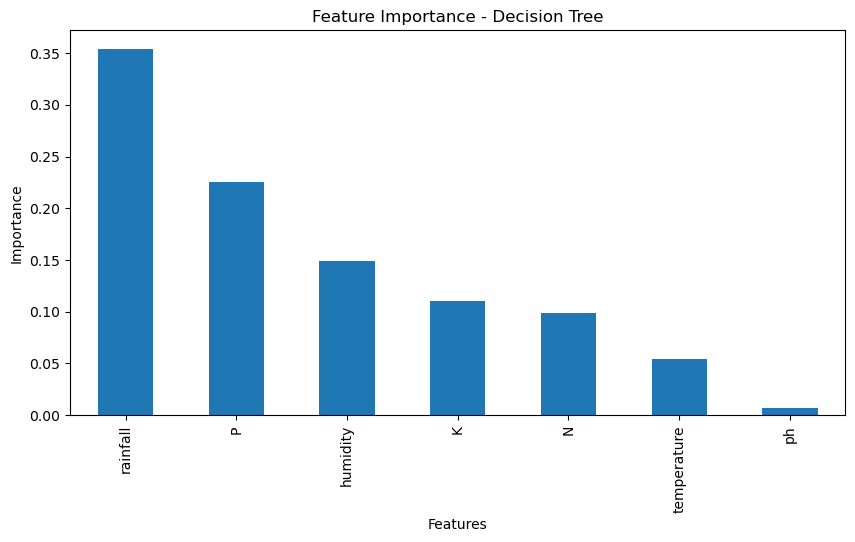

In [39]:
feature_importance.plot(kind="bar", figsize=(10, 5))
plt.title("Feature Importance - Decision Tree")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.xticks(rotation=90)
plt.show()

In [40]:
results=pd.DataFrame({"Model":["KNN","Decision Tree","Logistic Regression"],
                     "Accuracy":[accuracy_knn,accuracy_dt,accuracy_lr]})
results["Accuracy(%)"]=results["Accuracy"]*100
print(results)

                 Model  Accuracy  Accuracy(%)
0                  KNN  0.979545    97.954545
1        Decision Tree  0.979545    97.954545
2  Logistic Regression  0.972727    97.272727


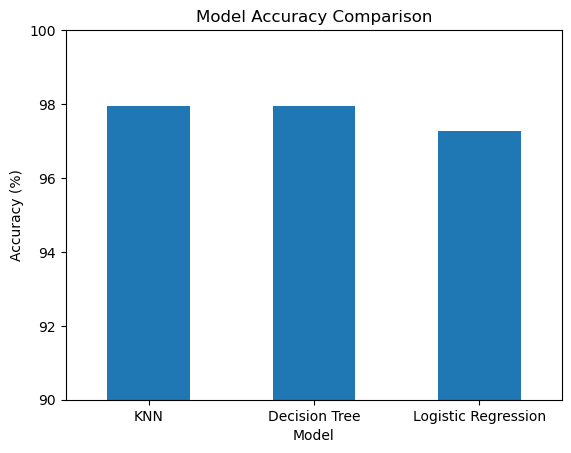

In [41]:
results.plot(x="Model",y="Accuracy(%)",kind="bar",legend=False)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy (%)")
plt.xlabel("Model")
plt.ylim(90, 100)
plt.xticks(rotation=0)
plt.show()

In [42]:
error_analysis=X_test.copy()
error_analysis["Actual"]=y_test
error_analysis["Predicted"]=y_pred_dt
error= error_analysis[error_analysis["Actual"]!=error_analysis["Predicted"]]
print("Number of incorrect predictions:",len(error))
error


Number of incorrect predictions: 9


,N,P,K,temperature,humidity,ph,rainfall,Actual,Predicted
768,23,57,19,32.839638,67.998036,7.251001,73.404527,blackgram,lentil
789,60,59,22,31.868473,66.742175,7.191523,74.222386,blackgram,maize
838,31,58,15,28.318869,60.194614,6.167855,45.365213,lentil,mothbeans
2094,93,43,38,23.614753,86.142903,6.987333,150.235524,jute,rice
769,42,58,25,27.458536,62.900210,6.513621,69.460209,blackgram,mothbeans
754,22,55,20,33.953091,69.961000,7.423530,61.163505,blackgram,lentil
526,8,60,18,31.216300,46.018682,3.808429,53.120528,mothbeans,lentil
83,67,43,39,26.043720,84.969072,5.999969,186.753677,rice,jute
839,28,58,25,27.481865,62.048150,6.861640,37.811240,lentil,mothbeans


In [43]:
error_pairs=error.groupby(["Actual","Predicted"]).size().sort_values(ascending=False)
print(error_pairs)

Actual     Predicted
blackgram  lentil       2
lentil     mothbeans    2
blackgram  maize        1
           mothbeans    1
jute       rice         1
mothbeans  lentil       1
rice       jute         1
dtype: int64


In [44]:
error_analysis_knn = X_test.copy()
error_analysis_knn["Actual"] = y_test
error_analysis_knn["Predicted"] = y_pred_knn
errors_knn = error_analysis_knn[error_analysis_knn["Actual"] != error_analysis_knn["Predicted"]]
print("Number of incorrect KNN predictions:", len(errors_knn))
errors_knn

Number of incorrect KNN predictions: 9


,N,P,K,temperature,humidity,ph,rainfall,Actual,Predicted
1645,40,22,6,24.536101,91.909972,6.488221,115.978799,orange,pomegranate
505,32,43,22,31.999286,54.107746,5.270749,71.626670,mothbeans,mango
525,36,56,20,25.412377,49.664743,7.437078,31.874170,mothbeans,lentil
1631,33,12,15,30.255780,92.032728,6.052318,116.717313,orange,coconut
408,35,58,20,29.385386,63.477420,5.761703,90.054227,pigeonpeas,mothbeans
482,5,68,20,19.043805,33.106951,6.121667,155.370562,pigeonpeas,kidneybeans
83,67,43,39,26.043720,84.969072,5.999969,186.753677,rice,jute
509,11,53,24,28.523967,55.772644,7.393899,61.329356,mothbeans,lentil
140,99,56,17,24.108592,73.131123,6.234330,71.075622,maize,cotton


In [45]:
# Count the different types of KNN errors
error_pairs_knn = (errors_knn.groupby(["Actual", "Predicted"]).size().sort_values(ascending=False))
print(error_pairs_knn)

Actual      Predicted  
mothbeans   lentil         2
maize       cotton         1
mothbeans   mango          1
orange      coconut        1
            pomegranate    1
pigeonpeas  kidneybeans    1
            mothbeans      1
rice        jute           1
dtype: int64


In [46]:
# Find incorrect Logistic Regression predictions
error_analysis_lr = X_test.copy()
error_analysis_lr["Actual"] = y_test
error_analysis_lr["Predicted"] = y_pred_lr
errors_lr = error_analysis_lr[error_analysis_lr["Actual"] != error_analysis_lr["Predicted"]]
print("Number of incorrect Logistic Regression predictions:", len(errors_lr))
errors_lr

Number of incorrect Logistic Regression predictions: 12


,N,P,K,temperature,humidity,ph,rainfall,Actual,Predicted
505,32,43,22,31.999286,54.107746,5.270749,71.626670,mothbeans,mango
813,27,80,24,28.420628,61.773363,7.815211,49.023668,lentil,blackgram
1631,33,12,15,30.255780,92.032728,6.052318,116.717313,orange,coconut
838,31,58,15,28.318869,60.194614,6.167855,45.365213,lentil,mothbeans
42,83,60,36,25.597049,80.145093,6.903986,200.834898,rice,jute
79,81,41,38,22.678461,83.728744,7.524080,200.913316,rice,jute
73,78,43,42,21.323763,83.003205,7.283737,192.319754,rice,jute
83,67,43,39,26.043720,84.969072,5.999969,186.753677,rice,jute
135,98,44,21,25.771751,74.089114,6.524478,107.493192,maize,cotton
570,23,58,19,24.170932,58.252046,5.243635,59.189534,mothbeans,lentil


In [47]:
error_pairs_lr = (errors_knn.groupby(["Actual", "Predicted"]).size().sort_values(ascending=False))
print(error_pairs_lr)

Actual      Predicted  
mothbeans   lentil         2
maize       cotton         1
mothbeans   mango          1
orange      coconut        1
            pomegranate    1
pigeonpeas  kidneybeans    1
            mothbeans      1
rice        jute           1
dtype: int64


In [48]:
"""
Error Analysis

The misclassified samples were reviewed using the confusion matrix. Most predictions were correct, while the remaining errors occurred between crop classes with similar soil and environmental conditions. This shows that some crops have overlapping feature ranges, which can make them harder for the model to distinguish.
"""

'\nError Analysis\n\nThe misclassified samples were reviewed using the confusion matrix. Most predictions were correct, while the remaining errors occurred between crop classes with similar soil and environmental conditions. This shows that some crops have overlapping feature ranges, which can make them harder for the model to distinguish.\n'

In [49]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

results = pd.DataFrame({
    "Model": ["KNN", "Decision Tree", "Logistic Regression"],

    "Accuracy": [
        accuracy_score(y_test, y_pred_knn),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_lr)
    ],

    "Precision": [
        precision_score(y_test, y_pred_knn, average="macro"),
        precision_score(y_test, y_pred_dt, average="macro"),
        precision_score(y_test, y_pred_lr, average="macro")
    ],

    "Recall": [
        recall_score(y_test, y_pred_knn, average="macro"),
        recall_score(y_test, y_pred_dt, average="macro"),
        recall_score(y_test, y_pred_lr, average="macro")
    ],

    "F1 Score": [
        f1_score(y_test, y_pred_knn, average="macro"),
        f1_score(y_test, y_pred_dt, average="macro"),
        f1_score(y_test, y_pred_lr, average="macro")
    ]
})

print(results.round(4))

                 Model  Accuracy  Precision  Recall  F1 Score
0                  KNN    0.9795     0.9804  0.9795    0.9793
1        Decision Tree    0.9795     0.9806  0.9795    0.9794
2  Logistic Regression    0.9727     0.9740  0.9727    0.9725


In [50]:
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))
print("Training labels:", len(y_train))
print("Testing labels:", len(y_test))

Training samples: 1760
Testing samples: 440
Training labels: 1760
Testing labels: 440


In [51]:
overlap=X_train.index.intersection(X_test.index)
print("Overlapping rows:",len(overlap))

Overlapping rows: 0


In [52]:
results_final = results
results_final["Accuracy"] = results_final["Accuracy"] * 100
results_final["Precision"] = results_final["Precision"] * 100
results_final["Recall"] = results_final["Recall"] * 100
results_final["F1 Score"] = results_final["F1 Score"] * 100
print(results_final)

                 Model   Accuracy  Precision     Recall   F1 Score
0                  KNN  97.954545  98.035550  97.954545  97.928323
1        Decision Tree  97.954545  98.059819  97.954545  97.942315
2  Logistic Regression  97.272727  97.402173  97.272727  97.246403


In [53]:
print(results_final.round(2))

                 Model  Accuracy  Precision  Recall  F1 Score
0                  KNN     97.95      98.04   97.95     97.93
1        Decision Tree     97.95      98.06   97.95     97.94
2  Logistic Regression     97.27      97.40   97.27     97.25


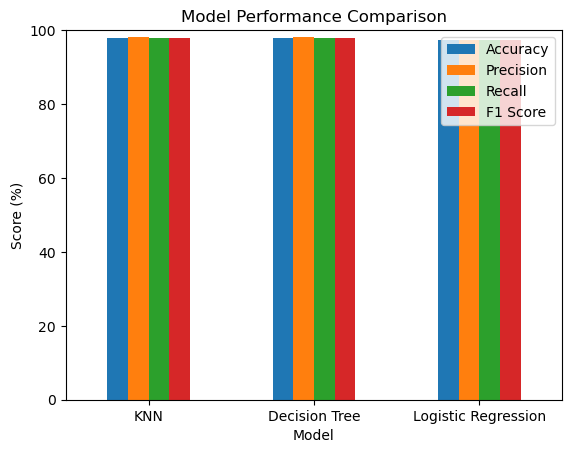

In [54]:
results.plot(x="Model",y=["Accuracy", "Precision", "Recall", "F1 Score"],kind="bar")
plt.title("Model Performance Comparison")
plt.ylabel("Score (%)")
plt.xlabel("Model")
plt.ylim(0, 100)
plt.xticks(rotation=0)
plt.legend()
plt.show()

In [55]:
from sklearn.metrics import roc_auc_score
knn_auc = roc_auc_score(y_test, knn.predict_proba(X_test_scaled), multi_class="ovr", average="weighted")
dt_auc = roc_auc_score(y_test, dt.predict_proba(X_test), multi_class="ovr", average="weighted")
lr_auc = roc_auc_score(y_test, lr.predict_proba(X_test_scaled), multi_class="ovr", average="weighted")
print("KNN ROC-AUC:", knn_auc)
print("Decision Tree ROC-AUC:", dt_auc)
print("Logistic Regression ROC-AUC:", lr_auc)

KNN ROC-AUC: 0.9987229437229436
Decision Tree ROC-AUC: 0.9892857142857144
Logistic Regression ROC-AUC: 0.999810606060606


In [56]:
"""
ROC-AUC was calculated using the One-vs-Rest approach because this is a multi-class classification problem. All three models achieved high ROC-AUC values, showing good separation between the crop classes.
"""

'\nROC-AUC was calculated using the One-vs-Rest approach because this is a multi-class classification problem. All three models achieved high ROC-AUC values, showing good separation between the crop classes.\n'

In [57]:
"""
Model Comparison
We tested KNN, Decision Tree and Logistic Regression.
KNN and Decision Tree both got 97.95% accuracy, while Logistic Regression got 97.27%.
Decision Tree was selected for the prototype because it gives similar accuracy to KNN and is easier to understand and explain.
So, Decision Tree is used for the final crop prediction.
"""

'\nModel Comparison\nWe tested KNN, Decision Tree and Logistic Regression.\nKNN and Decision Tree both got 97.95% accuracy, while Logistic Regression got 97.27%.\nDecision Tree was selected for the prototype because it gives similar accuracy to KNN and is easier to understand and explain.\nSo, Decision Tree is used for the final crop prediction.\n'

In [58]:
"""
The three models gave high performance on the test data. KNN and Decision Tree achieved the same accuracy of 97.95%, while Logistic Regression achieved 97.27%.
The Decision Tree was selected for the final prototype because its performance was comparable to KNN and it provides feature importance, which helps us understand which input features contribute to the prediction. It also does not require feature scaling, making it simple to use in the application.
"""

'\nThe three models gave high performance on the test data. KNN and Decision Tree achieved the same accuracy of 97.95%, while Logistic Regression achieved 97.27%.\nThe Decision Tree was selected for the final prototype because its performance was comparable to KNN and it provides feature importance, which helps us understand which input features contribute to the prediction. It also does not require feature scaling, making it simple to use in the application.\n'

In [59]:
new_data = [[90, 42, 42, 25, 80, 6.5, 100]]
prediction = dt.predict(new_data)
print("Recommended crop:", prediction[0])

Recommended crop: jute


C:\Users\SHINCHAN\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [60]:
"""
Prediction Result
For the given soil and environmental conditions, the model predicted **jute** as the suitable crop.
This shows that the trained Decision Tree can take new input values and give a crop prediction.
"""

'\nPrediction Result\nFor the given soil and environmental conditions, the model predicted **jute** as the suitable crop.\nThis shows that the trained Decision Tree can take new input values and give a crop prediction.\n'

In [ ]:
"""
This project developed a machine learning based crop recommendation system using soil and environmental conditions such as nitrogen, phosphorus, potassium, temperature, humidity, pH and rainfall. Three classification models, KNN, Decision Tree and Logistic Regression, were trained and evaluated using multiple performance metrics.
The models showed high classification performance on the test data. ROC-AUC was also evaluated using the One-vs-Rest approach for the multi-class problem. The final Decision Tree model was saved as a pickle file and used for crop prediction.
The trained model can be integrated with a simple user interface where users enter the required soil and environmental values and receive a recommended crop.
"""

In [ ]:
"""
Limitations
The model is trained using the available dataset, so its predictions may not represent every real-world farming condition. The dataset contains specific soil and environmental ranges, and performance may vary when values outside these ranges are provided. The recommendation is based only on the features used in the dataset and does not consider other factors such as soil texture, irrigation facilities, season, or local farming practices.
The model should therefore be treated as a decision-support tool rather than a replacement for expert agricultural advice.